## Task

In [72]:
import pandas as pd

# Define the data for the table
data = {
    'Task': [
        'Deep Unidirectional RNN Model with an embedding layer','', 'Training Data Check', '', '','','Feature Engg', '','Feature Engg','','','','','Cross Validation',
        'Interpretability', 'Testing Data Check', '','',''
    ],
    'Status': [
        'Config of the model trained','', 'Confusion Matrix Built', '','AUC Plotted','Accuracy calculated', 'Tokenization and Padding','','Training Time after Feature Engg','Confusion Matrix Built','','AUC','Accuracy Calculated',
        'Done', 'Local Interpretability using Lime', 'Confusion Matrix Built', '','AUC', 'Accuracy Calculated'
    ]
}

# Create a DataFrame
task_status = pd.DataFrame(data)

# Display the table
task_status

,Task,Status
0,Deep Unidirectional RNN Model with an embeddin...,Config of the model trained
1,,
2,Training Data Check,Confusion Matrix Built
3,,
4,,AUC Plotted
5,,Accuracy calculated
6,Feature Engg,Tokenization and Padding
7,,
8,Feature Engg,Training Time after Feature Engg
9,,Confusion Matrix Built


## Imports

In [1]:
import pandas as pd
import numpy as np
import re
import emoji
import contractions
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, SpatialDropout1D
from imblearn.over_sampling import SMOTE
import time
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Load Dataset

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\JISNA\Desktop\sem 3\NLP\Sentiment_Data.csv", encoding='ISO-8859-1')
df = df.sample(30000, random_state=42)  # Take a sample of 30,000
df

,Tweet,Sentiment
420483,stupid fucking freedom convoy is going past th...,Strong_Neg
320604,Freedom Convoy coming to a country near you! S...,Strong_Pos
68154,@CTVNews The main thing is that the Freedom/An...,Neutral
100473,Residents who Chauvin says previously agreed t...,Mild_Pos
303998,MSNBC guest says Freedom Convoy truckers throw...,Mild_Pos
...,...,...
58427,âFreedom fighters of Baloch Liberation Army ...,Mild_Neg
293334,What's happening there?\n#Police helping #Free...,Strong_Neg
159915,âPEOPLES CONVOY LIVE HAGERSTOWN MD 2022 RIDI...,Strong_Pos
408239,So you used him as a virtue signal for your cu...,Mild_Pos


In [35]:
# Check for null values
null_values = df.isnull().sum()
print("Null values in each column:")
print(null_values)

Null values in each column:
Tweet        0
Sentiment    0
dtype: int64


In [3]:
df.columns

Index(['Tweet', 'Sentiment'], dtype='object')

## Data Preprocessing

### Text Cleaning, Emoji Handiling, Contractions

In [4]:
# Regex-based Cleaning Functions
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text)  # Remove hashtags
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters
    return text

def handle_emojis(text):
    return emoji.demojize(text)

def expand_contractions(text):
    return contractions.fix(text)

### Slang and Abbreviation Handling

In [5]:
# Slang and Abbreviation Handling
slang_dict = {"u": "you", "ur": "your", "idk": "i don't know", "btw": "by the way", "smh": "shaking my head"}

def replace_slang(text):
    words = text.split()
    return ' '.join([slang_dict[word] if word in slang_dict else word for word in words])

# Apply Preprocessing
df['Tweet'] = df['Tweet'].apply(clean_text)
df['Tweet'] = df['Tweet'].apply(handle_emojis)
df['Tweet'] = df['Tweet'].apply(expand_contractions)
df['Tweet'] = df['Tweet'].apply(replace_slang)

### Tokenization and Stopword Removal

In [6]:
# Tokenization and Stopword Removal
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['Tweet'] = df['Tweet'].apply(preprocess_text)

### Label Encoding

In [7]:
# Label Encoding
df['Sentiment'] = df['Sentiment'].map({'Mild_Pos': 2, 'Strong_Pos': 2, 'Neutral': 1, 'Mild_Neg': 0, 'Strong_Neg': 0})

## Data Splitting

In [8]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(df['Tweet'], df['Sentiment'], test_size=0.2, random_state=42)

### Class Seperatability

In [9]:
# # Convert y_train and y_test to integer type (in case they are objects or strings)
# y_train = y_train.astype(int)
# y_test = y_test.astype(int)
# Print unique values in y_train
print("Unique values in y_train:", y_train.unique())

# Print unique values in y_test
print("Unique values in y_test:", y_test.unique())


Unique values in y_train: [2 1 0]
Unique values in y_test: [2 0 1]


### Tokenization and Padding

In [10]:
# Tokenization and Padding
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=50)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=50)

## Model Building

In [11]:
model = Sequential([
    Embedding(input_dim=5000, output_dim=128),
    SpatialDropout1D(0.2),
    SimpleRNN(100, activation='relu'),
    Dense(3, activation='softmax')
])

# Ensure model builds correctly
model.build(input_shape=(None, 50))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


# Summary of the model to verify the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 50, 128)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (None, 50, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 100)                 │          22,900 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │             303 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 663,203 (2.53 MB)

 Trainable params: 663,203 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training and Evaluation

In [12]:
# Training the Model

start_time = time.time()

history = model.fit(X_train_seq, y_train, epochs=10, batch_size=64, validation_data=(X_test_seq, y_test))

end_time = time.time()

print(f"Total Training Time: {end_time - start_time:.2f} seconds")

# Model Evaluation
loss, accuracy = model.evaluate(X_test_seq, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.6787 - loss: 0.7914 - val_accuracy: 0.7745 - val_loss: 0.5991
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8102 - loss: 0.5105 - val_accuracy: 0.7862 - val_loss: 0.5824
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8549 - loss: 0.3934 - val_accuracy: 0.7687 - val_loss: 0.6132
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.8923 - loss: 0.3060 - val_accuracy: 0.7773 - val_loss: 0.7293
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9238 - loss: 0.2225 - val_accuracy: 0.7593 - val_loss: 0.7693
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9392 - loss: 0.1776 - val_accuracy: 0.7678 - val_loss: 0.8649
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9536 - loss: 0.1415 - val_accuracy: 0.7693 - val_loss: 1.0444
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9628 - loss: 0.1158 - va

### AUC, ROC & Confusion matrix

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
AUC (Macro Average): 0.8070


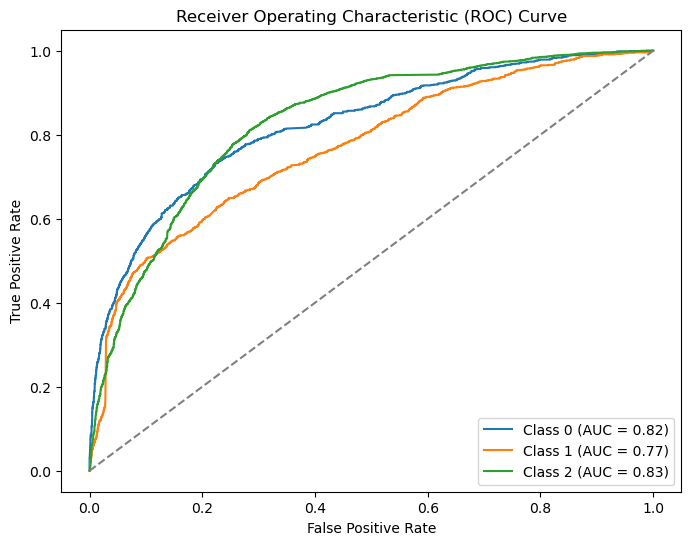

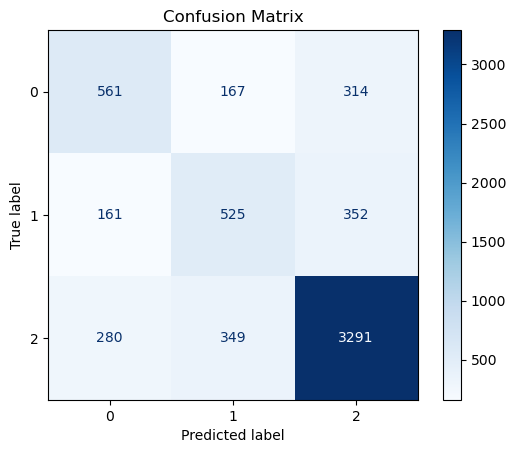

In [13]:
# 1. Predict probabilities for ROC and AUC
y_pred_prob = model.predict(X_test_seq)

# 2. Label Binarizer: Convert multi-class labels to binary format for each class
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

# 3. AUC Calculation for Multi-Class (One-vs-Rest)
auc = roc_auc_score(y_test_bin, y_pred_prob, average='macro', multi_class='ovr')
print(f"AUC (Macro Average): {auc:.4f}")

# 4. ROC Curve for each class (One-vs-Rest)
n_classes = y_pred_prob.shape[1]
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {lb.classes_[i]} (AUC = {roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i]):.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# 5. Confusion Matrix
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class predictions
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lb.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


### Accuracy, Precision, Recall & F1 score

In [15]:
# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)

# Compute precision, recall, and F1-score for multiclass classification
precision = precision_score(y_test, y_pred, average='macro')  # Change to 'micro' or 'weighted' if needed
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Full classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7295
Precision: 0.6320
Recall: 0.6279
F1 Score: 0.6299

Classification Report:

              precision    recall  f1-score   support

           0       0.56      0.54      0.55      1042
           1       0.50      0.51      0.51      1038
           2       0.83      0.84      0.84      3920

    accuracy                           0.73      6000
   macro avg       0.63      0.63      0.63      6000
weighted avg       0.73      0.73      0.73      6000



In [16]:
# F1 Score for Negative Class (0)
f1_negative = f1_score(y_test, y_pred, labels=[0], average=None)[0]

# F1 Score for Neutral Class (1)
f1_neutral = f1_score(y_test, y_pred, labels=[1], average=None)[0]

# F1 Score for Positive Class (2)
f1_positive = f1_score(y_test, y_pred, labels=[2], average=None)[0]

print(f"F1 Score (Negative Class - 0): {f1_negative:.4f}")
print(f"F1 Score (Neutral Class - 1): {f1_neutral:.4f}")
print(f"F1 Score (Positive Class - 2): {f1_positive:.4f}")


F1 Score (Negative Class - 0): 0.5489
F1 Score (Neutral Class - 1): 0.5051
F1 Score (Positive Class - 2): 0.8356


In [17]:
# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 561  167  314]
 [ 161  525  352]
 [ 280  349 3291]]


## Class Balancing - SMOTE

In [18]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_seq, y_train)

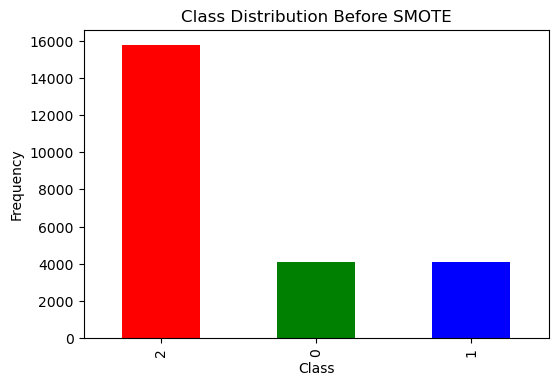

In [19]:
# Plot the distribution of classes before SMOTE
plt.figure(figsize=(6, 4))
y_train.value_counts().plot(kind='bar', color=['red', 'green', 'blue'])
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()


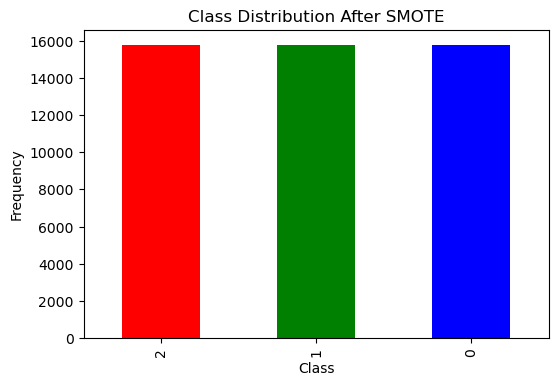

In [20]:
# Plot the distribution of classes after SMOTE
plt.figure(figsize=(6, 4))
y_train_resampled.value_counts().plot(kind='bar', color=['red', 'green', 'blue'])
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()


## Model Training and Evaluation

In [21]:
# Training the Model

start_time = time.time()

history = model.fit(X_train_seq, y_train, epochs=10, batch_size=64, validation_data=(X_test_seq, y_test))

end_time = time.time()

print(f"Total Training Time: {end_time - start_time:.2f} seconds")

# Model Evaluation
loss, accuracy = model.evaluate(X_test_seq, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9770 - loss: 0.0728 - val_accuracy: 0.7457 - val_loss: 1.2488
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9752 - loss: 0.0777 - val_accuracy: 0.7455 - val_loss: 1.2321
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9757 - loss: 0.0705 - val_accuracy: 0.7487 - val_loss: 1.2878
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9795 - loss: 0.0650 - val_accuracy: 0.7593 - val_loss: 1.5637
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9819 - loss: 0.0567 - val_accuracy: 0.7440 - val_loss: 1.4319
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9822 - loss: 0.0586 - val_accuracy: 0.7315 - val_loss: 1.4421
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9812 - loss: 0.0560 - val_accuracy: 0.7368 - val_loss: 1.5340
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9850 - loss: 0.0494 - val_

### AUC, ROC & Confusion matrix

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
AUC (Macro Average): 0.8128


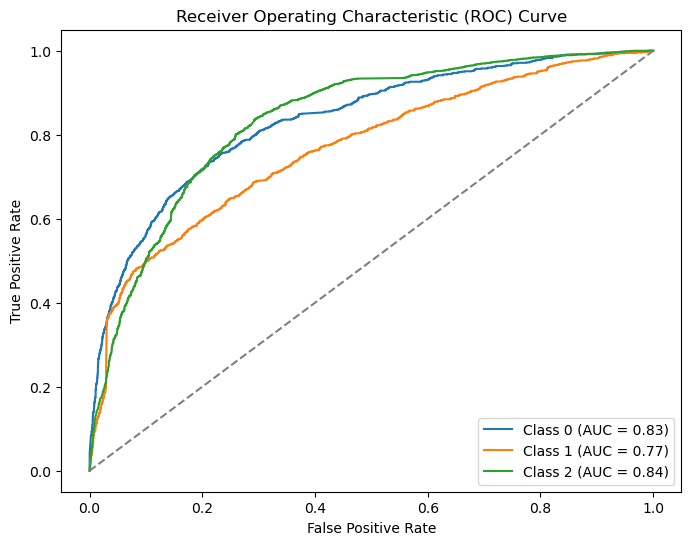

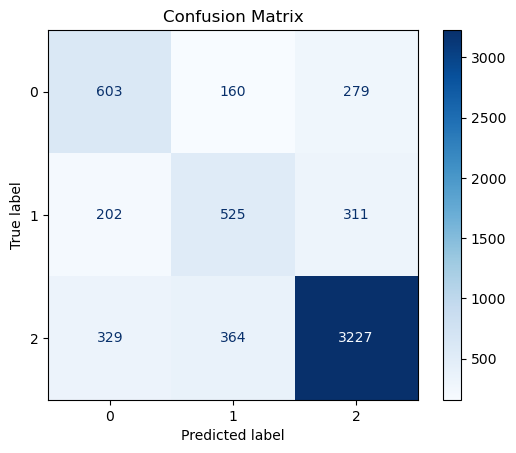

In [22]:
# 1. Predict probabilities for ROC and AUC
y_pred_prob = model.predict(X_test_seq)

# 2. Label Binarizer: Convert multi-class labels to binary format for each class
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

# 3. AUC Calculation for Multi-Class (One-vs-Rest)
auc = roc_auc_score(y_test_bin, y_pred_prob, average='macro', multi_class='ovr')
print(f"AUC (Macro Average): {auc:.4f}")

# 4. ROC Curve for each class (One-vs-Rest)
n_classes = y_pred_prob.shape[1]
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {lb.classes_[i]} (AUC = {roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i]):.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# 5. Confusion Matrix
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class predictions
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lb.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [23]:
# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 603  160  279]
 [ 202  525  311]
 [ 329  364 3227]]


### Accuracy, Precision, Recall & F1 score

In [24]:
# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)

# Compute precision, recall, and F1-score for multiclass classification
precision = precision_score(y_test, y_pred, average='macro')  # Change to 'micro' or 'weighted' if needed
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Full classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7258
Precision: 0.6259
Recall: 0.6359
F1 Score: 0.6305

Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.58      0.55      1042
           1       0.50      0.51      0.50      1038
           2       0.85      0.82      0.83      3920

    accuracy                           0.73      6000
   macro avg       0.63      0.64      0.63      6000
weighted avg       0.73      0.73      0.73      6000



In [25]:
# F1 Score for Negative Class (0)
f1_negative = f1_score(y_test, y_pred, labels=[0], average=None)[0]

# F1 Score for Neutral Class (1)
f1_neutral = f1_score(y_test, y_pred, labels=[1], average=None)[0]

# F1 Score for Positive Class (2)
f1_positive = f1_score(y_test, y_pred, labels=[2], average=None)[0]

print(f"F1 Score (Negative Class - 0): {f1_negative:.4f}")
print(f"F1 Score (Neutral Class - 1): {f1_neutral:.4f}")
print(f"F1 Score (Positive Class - 2): {f1_positive:.4f}")


F1 Score (Negative Class - 0): 0.5542
F1 Score (Neutral Class - 1): 0.5031
F1 Score (Positive Class - 2): 0.8342


### Training and Validation - Loss and Accuracy Curve

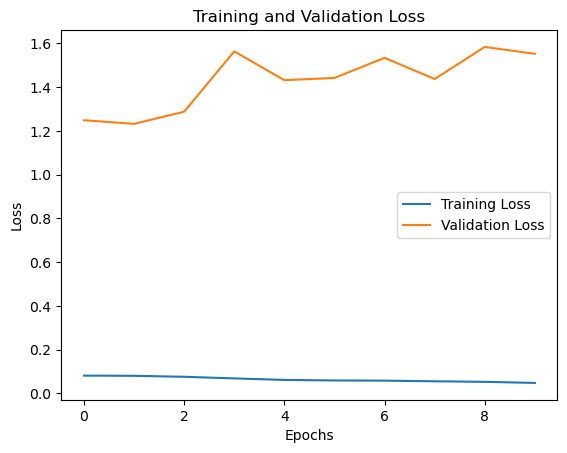

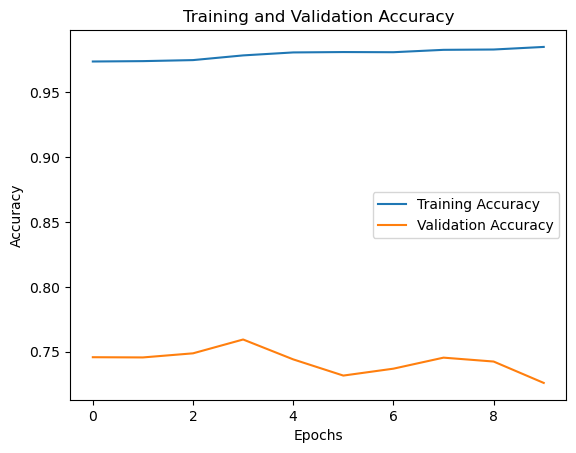

In [26]:
# Plotting the loss curves
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plotting the accuracy curves
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [27]:
# Evaluate the model on training and test data
train_loss, train_accuracy = model.evaluate(X_train_seq, y_train)
test_loss, test_accuracy = model.evaluate(X_test_seq, y_test)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9879 - loss: 0.0311
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7375 - loss: 1.4590
Training Accuracy: 98.81%
Test Accuracy: 72.58%


## Overfitting Handling - Early Stopping

In [28]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model with early stopping

start_time = time.time()

history = model.fit(X_train_seq, y_train, epochs=10, batch_size=64, validation_data=(X_test_seq, y_test), callbacks=[early_stopping])

end_time = time.time()

print(f"Total Training Time: {end_time - start_time:.2f} seconds")

# Model Evaluation
loss, accuracy = model.evaluate(X_test_seq, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9862 - loss: 0.0419 - val_accuracy: 0.7392 - val_loss: 1.5700
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9880 - loss: 0.0370 - val_accuracy: 0.7383 - val_loss: 1.5645
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9890 - loss: 0.0353 - val_accuracy: 0.7448 - val_loss: 1.5790
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9841 - loss: 0.0503 - val_accuracy: 0.7445 - val_loss: 1.6844
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9869 - loss: 0.0415 - val_accuracy: 0.7422 - val_loss: 1.9869
Total Training Time: 46.21 seconds
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7468 - loss: 1.4786
Test Accuracy: 73.83%


### AUC, ROC, Confusion matrix

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
AUC (Macro Average): 0.8077


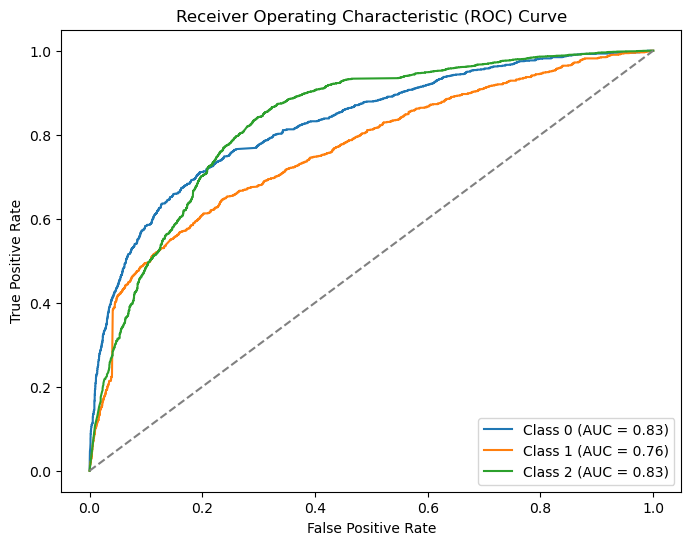

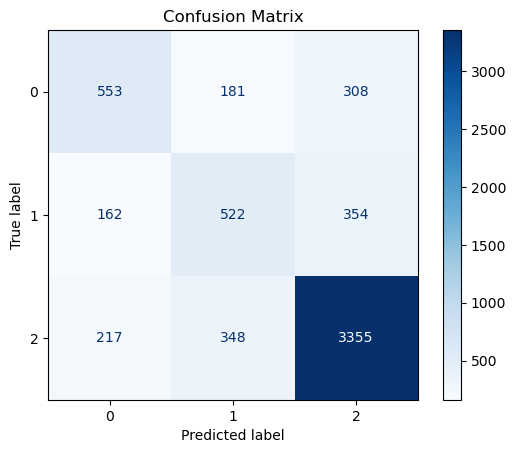

In [29]:
# 1. Predict probabilities for ROC and AUC
y_pred_prob = model.predict(X_test_seq)

# 2. Label Binarizer: Convert multi-class labels to binary format for each class
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

# 3. AUC Calculation for Multi-Class (One-vs-Rest)
auc = roc_auc_score(y_test_bin, y_pred_prob, average='macro', multi_class='ovr')
print(f"AUC (Macro Average): {auc:.4f}")

# 4. ROC Curve for each class (One-vs-Rest)
n_classes = y_pred_prob.shape[1]
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {lb.classes_[i]} (AUC = {roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i]):.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# 5. Confusion Matrix
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class predictions
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lb.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [30]:
# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 553  181  308]
 [ 162  522  354]
 [ 217  348 3355]]


### Accuracy, Precision, Recall & F1 Score

In [31]:
# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)

# Compute precision, recall, and F1-score for multiclass classification
precision = precision_score(y_test, y_pred, average='macro')  # Change to 'micro' or 'weighted' if needed
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Full classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7383
Precision: 0.6417
Recall: 0.6298
F1 Score: 0.6352

Classification Report:

              precision    recall  f1-score   support

           0       0.59      0.53      0.56      1042
           1       0.50      0.50      0.50      1038
           2       0.84      0.86      0.85      3920

    accuracy                           0.74      6000
   macro avg       0.64      0.63      0.64      6000
weighted avg       0.73      0.74      0.74      6000



In [32]:
# F1 Score for Negative Class (0)
f1_negative = f1_score(y_test, y_pred, labels=[0], average=None)[0]

# F1 Score for Neutral Class (1)
f1_neutral = f1_score(y_test, y_pred, labels=[1], average=None)[0]

# F1 Score for Positive Class (2)
f1_positive = f1_score(y_test, y_pred, labels=[2], average=None)[0]

print(f"F1 Score (Negative Class - 0): {f1_negative:.4f}")
print(f"F1 Score (Neutral Class - 1): {f1_neutral:.4f}")
print(f"F1 Score (Positive Class - 2): {f1_positive:.4f}")


F1 Score (Negative Class - 0): 0.5603
F1 Score (Neutral Class - 1): 0.4998
F1 Score (Positive Class - 2): 0.8454


###  Training and Validation - Loss and Accuracy Curve

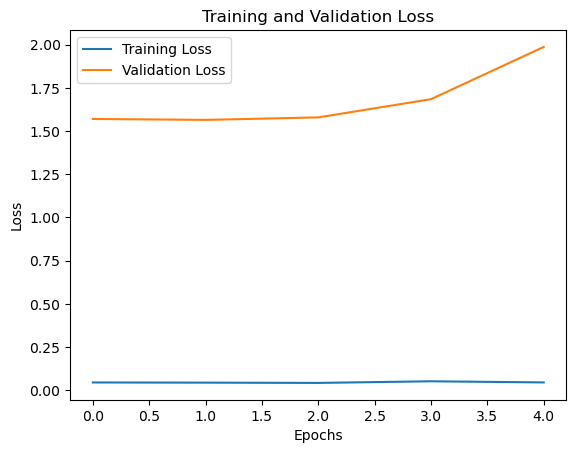

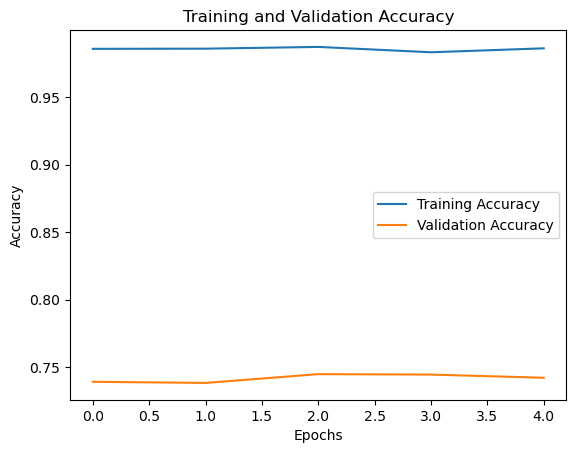

In [33]:
# Plotting the loss curves
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plotting the accuracy curves
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [34]:
# Evaluate the model on training and test data
train_loss, train_accuracy = model.evaluate(X_train_seq, y_train)
test_loss, test_accuracy = model.evaluate(X_test_seq, y_test)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9924 - loss: 0.0253
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7468 - loss: 1.4786
Training Accuracy: 99.26%
Test Accuracy: 73.83%


In [39]:
print(shap_values.shape)  # Should be (100, num_features)
print(X_test_seq[:100].shape)  # Should match the input shape expected by the model

(100, 50, 3)
(100, 50)


### Extraction of Embedding weights

In [44]:
embedding_weights = model.layers[0].get_weights()[0]  # Get the weights from the Embedding layer
word_index = tokenizer.word_index
reverse_word_index = {index: word for word, index in word_index.items()}

word_weights = {}

# Iterate through the word_index and get the weight norms for words that are within the embedding range
for word, index in word_index.items():
    if index < len(embedding_weights):  # Ensure the index is within the bounds of the embedding matrix
        word_weights[word] = np.linalg.norm(embedding_weights[index])

# Sort words by their "importance" based on the embedding norm
sorted_word_weights = sorted(word_weights.items(), key=lambda item: item[1], reverse=True)

# Print the top 10 important words
print("Top 10 important words based on embedding weights:")
for word, weight in sorted_word_weights[:10]:
    print(f"Word: {word}, Importance: {weight}")


Top 10 important words based on embedding weights:
Word: terrorizing, Importance: 2.636404275894165
Word: disappointed, Importance: 2.3034963607788086
Word: perfectly, Importance: 2.298982858657837
Word: superior, Importance: 2.2892985343933105
Word: amazing, Importance: 2.2493042945861816
Word: brilliant, Importance: 2.232879877090454
Word: perfect, Importance: 2.223670482635498
Word: inspiring, Importance: 2.2215750217437744
Word: successful, Importance: 2.2129390239715576
Word: awesome, Importance: 2.189340114593506


### PCA 

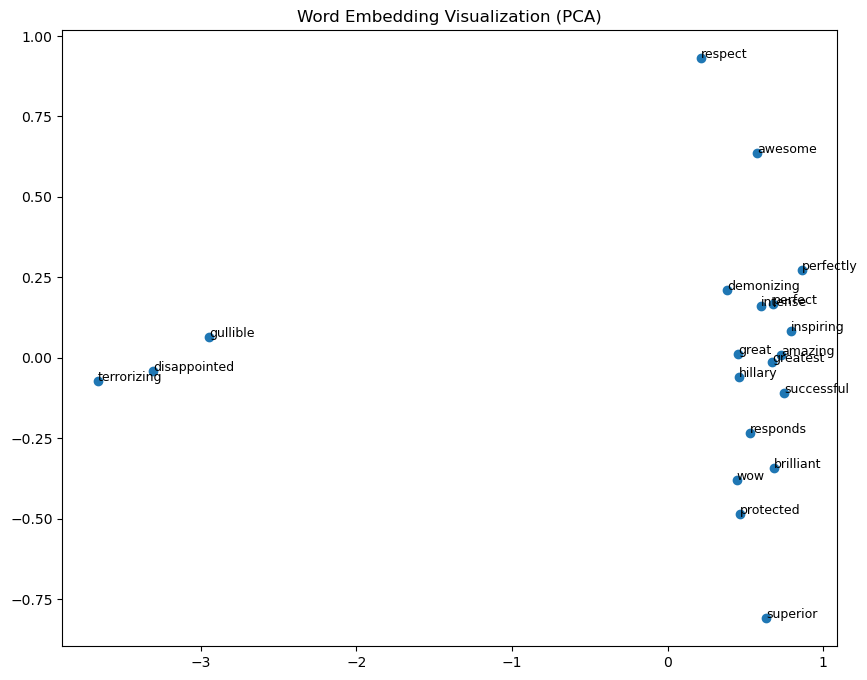

In [69]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Select top 100 words based on importance
top_words = [word for word, _ in sorted_word_weights[:20]]

# Prepare the embeddings for the top words
word_embeddings = []
word_labels = []

for word in top_words:
    index = word_index.get(word)
    if index and index < embedding_weights.shape[0]:
        word_embeddings.append(embedding_weights[index])
        word_labels.append(word)

word_embeddings = np.array(word_embeddings)

# Step 2: Reduce dimensionality (Using PCA or t-SNE)

# Option 1: PCA (Principal Component Analysis)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(word_embeddings)

# Step 3: Plot the results
plt.figure(figsize=(10, 8))

# Plotting PCA results
plt.scatter(pca_result[:, 0], pca_result[:, 1])

for i, word in enumerate(word_labels):
    plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]), fontsize=9)  # Annotate points with word labels

plt.title('Word Embedding Visualization (PCA)')
plt.show()


## Cross Validation

In [ ]:
# Define the model architecture
def create_model():
    model = Sequential([
        Input(shape=(X_train_resampled.shape[1],)),  # Input shape matches resampled data
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')  # Binary classification (adjust if needed)
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])
    return model

# Define Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
fold_results = []
y_true_all = []  # List to store true labels across folds
y_pred_prob_all = []  # List to store predicted probabilities across folds

# Cross-Validation loop
for fold, (train_index, val_index) in enumerate(kf.split(X_train_resampled, y_train_resampled), 1):
    # Split resampled data into training and validation sets
    X_train_fold, X_val_fold = X_train_resampled[train_index], X_train_resampled[val_index]
    y_train_fold, y_val_fold = y_train_resampled[train_index], y_train_resampled[val_index]
    
    # Create a new instance of the model for each fold
    model = create_model()
    
    # Start timer for training
    start_time = time.time()
    
    # Train the model
    history = model.fit(X_train_fold, y_train_fold, 
                        epochs=10, batch_size=32, verbose=0, 
                        validation_data=(X_val_fold, y_val_fold))
    
    # Calculate training time for this fold
    training_time = time.time() - start_time
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    
    # Store results for this fold
    fold_results.append({
        'Fold': fold,
        'Accuracy': accuracy * 100,  # Convert to percentage
        'Training Time (s)': training_time
    })
    
    # Store true labels and predicted probabilities for ROC curve and confusion matrix
    y_true_all.append(y_val_fold)
    y_pred_prob_all.append(model.predict(X_val_fold))  # Store predicted probabilities

# Convert results to a DataFrame for summary
results_df = pd.DataFrame(fold_results)

# Print summary table
print(results_df)

# Combine true labels and predicted probabilities from all folds
y_true_all = np.concatenate(y_true_all, axis=0)
y_pred_prob_all = np.concatenate(y_pred_prob_all, axis=0)

# For binary classification, you can binarize the true labels (if needed)
y_true_binarized = label_binarize(y_true_all, classes=[0, 1])  # Adjust class labels if needed

# Compute Confusion Matrix
y_pred = (y_pred_prob_all > 0.5).astype(int)  # Binary predictions based on threshold of 0.5
cm = confusion_matrix(y_true_all, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

## Interpretability

### LIME

In [47]:
import lime
import lime.lime_text

# Function to predict for LIME
def predict_proba(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=50)
    return model.predict(padded_sequences)

# Initialize the LIME text explainer
explainer = lime.lime_text.LimeTextExplainer(class_names=['Negative', 'Neutral', 'Positive'])

# Choose a text instance from the test set for explanation (example here is the first instance in the test set)
text_instance = X_test.iloc[0]  # You can pick any text instance from the test set

# Explain the prediction for the selected instance
explanation = explainer.explain_instance(text_instance, predict_proba, num_features=10)

# Display the explanation in the notebook
explanation.show_in_notebook(text=True)

# You can also print out the explanation for the selected instance
print(f"Explanation for the instance: {text_instance}")
explanation.as_list()  # Display the most important features (words)


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


Explanation for the instance: bidens handler pushed trudeau crack freedom convoy


[('freedom', -0.4068737443107235),
 ('bidens', -0.292182873336024),
 ('convoy', -0.08832012323677624),
 ('crack', -0.08129323851768085),
 ('handler', -0.017695988812476963),
 ('trudeau', 0.014592378819930512),
 ('pushed', 0.0005590827058434862)]

In [48]:
!pip install keras-tuner


   ---------------------------------------- 0.0/129.1 kB ? eta -:--:--
   --- ------------------------------------ 10.2/129.1 kB ? eta -:--:--
   --------- ----------------------------- 30.7/129.1 kB 435.7 kB/s eta 0:00:01
   --------------- ----------------------- 51.2/129.1 kB 435.7 kB/s eta 0:00:01
   --------------------- ----------------- 71.7/129.1 kB 491.5 kB/s eta 0:00:01
   ------------------------------ ------- 102.4/129.1 kB 492.8 kB/s eta 0:00:01
   -------------------------------------- 129.1/129.1 kB 508.1 kB/s eta 0:00:00


## Hyper Parameter Tunning

In [49]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam

# Hyperparameter tuning function
def build_model(hp):
    model = Sequential()
    
    # Embedding layer
    model.add(Embedding(input_dim=5000, output_dim=128, input_length=50))
    
    # Spatial Dropout with hyperparameter search for the dropout rate
    model.add(SpatialDropout1D(rate=hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))
    
    # RNN layer with hyperparameter search for the number of units
    model.add(SimpleRNN(units=hp.Int('units', min_value=50, max_value=200, step=50), activation='relu'))
    
    # Dense output layer with 3 classes
    model.add(Dense(3, activation='softmax'))
    
    # Compile the model with a learning rate as a hyperparameter
    model.compile(optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model


### Round 1 & Round 2

In [50]:
# Initialize the tuner with RandomSearch
tuner = kt.RandomSearch(
    build_model,  # The model-building function
    objective='val_accuracy',  # What to optimize
    max_trials=10,  # Number of trials to run in each round
    executions_per_trial=1,  # Number of executions per trial
    directory='kt_dir',  # Directory to store results
    project_name='rnn_tuning'  # Project name
)

# Round 1: Perform hyperparameter search
tuner.search(X_train_seq, y_train, epochs=5, batch_size=64, validation_data=(X_test_seq, y_test))

# Get the best model from Round 1
best_model_round_1 = tuner.get_best_models(num_models=1)[0]
best_model_round_1.summary()

# Round 2: Perform hyperparameter search with adjusted search space or just re-run
# Optionally, you can change the search space or parameters here.
tuner.search(X_train_seq, y_train, epochs=5, batch_size=64, validation_data=(X_test_seq, y_test))

# Get the best model from Round 2
best_model_round_2 = tuner.get_best_models(num_models=1)[0]
best_model_round_2.summary()

# Evaluate the best model from Round 2
loss, accuracy = best_model_round_2.evaluate(X_test_seq, y_test)
print(f"Test Accuracy from Round 2: {accuracy * 100:.2f}%")


Trial 10 Complete [00h 01m 24s]
val_accuracy: 0.7836666703224182

Best val_accuracy So Far: 0.7860000133514404
Total elapsed time: 00h 09m 17s


C:\Users\JISNA\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (64, 50, 128)               │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (64, 50, 128)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (64, 150)                   │          41,850 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (64, 3)                     │             453 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 682,303 (2.60 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (64, 50, 128)               │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (64, 50, 128)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (64, 150)                   │          41,850 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (64, 3)                     │             453 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 682,303 (2.60 MB)

 Trainable params: 682,303 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7930 - loss: 0.5818
Test Accuracy from Round 2: 78.60%


### AUC, ROC, Confusion matrix

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
AUC (Macro Average): 0.8507


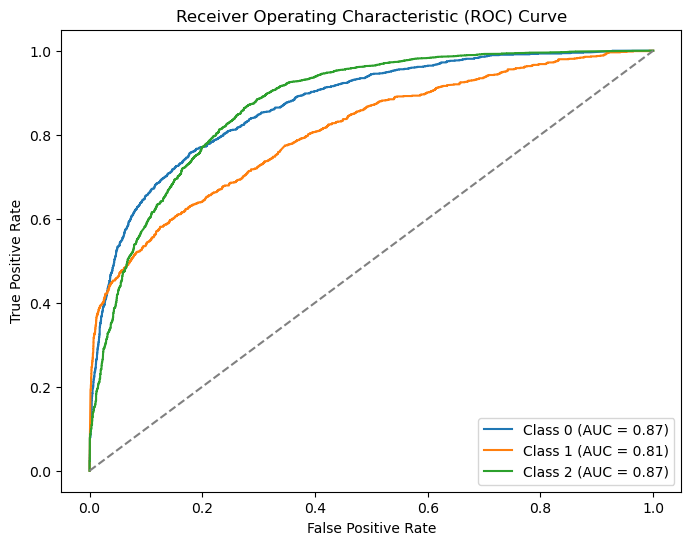

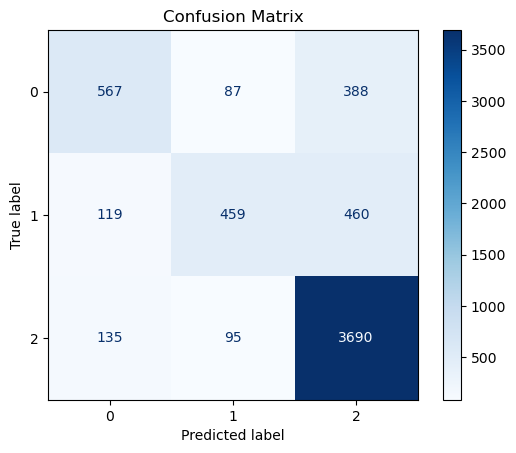

In [60]:
from sklearn.metrics import roc_curve, auc as calculate_auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelBinarizer

# Predict probabilities using the best model after hyperparameter tuning
y_pred_prob = best_model_round_2.predict(X_test_seq)

# Convert multi-class labels to binary format using LabelBinarizer
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

# 1. Calculate AUC (Macro Average)
auc_macro = roc_auc_score(y_test_bin, y_pred_prob, average='macro', multi_class='ovr')
print(f"AUC (Macro Average): {auc_macro:.4f}")

# 2. Plot ROC Curve for each class (One-vs-Rest)
n_classes = y_pred_prob.shape[1]
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = calculate_auc(fpr, tpr)  # AUC for each class
    plt.plot(fpr, tpr, label=f'Class {lb.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# 3. Confusion Matrix
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class predictions
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lb.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


### Accuracy, Precision, Recall & F1 Score

In [61]:
# Predict the class labels
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class predictions

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)

# Compute precision, recall, and F1-score for multiclass classification
precision = precision_score(y_test, y_pred, average='macro')  # Change to 'micro' or 'weighted' if needed
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro Average): {precision:.4f}")
print(f"Recall (Macro Average): {recall:.4f}")
print(f"F1 Score (Macro Average): {f1:.4f}")

# Full classification report (per-class performance)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# F1 Score for Negative Class (0)
f1_negative = f1_score(y_test, y_pred, labels=[0], average=None)[0]

# F1 Score for Neutral Class (1)
f1_neutral = f1_score(y_test, y_pred, labels=[1], average=None)[0]

# F1 Score for Positive Class (2)
f1_positive = f1_score(y_test, y_pred, labels=[2], average=None)[0]

print(f"F1 Score (Negative Class - 0): {f1_negative:.4f}")
print(f"F1 Score (Neutral Class - 1): {f1_neutral:.4f}")
print(f"F1 Score (Positive Class - 2): {f1_positive:.4f}")


Accuracy: 0.7860
Precision (Macro Average): 0.7399
Recall (Macro Average): 0.6426
F1 Score (Macro Average): 0.6760

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.54      0.61      1042
           1       0.72      0.44      0.55      1038
           2       0.81      0.94      0.87      3920

    accuracy                           0.79      6000
   macro avg       0.74      0.64      0.68      6000
weighted avg       0.78      0.79      0.77      6000

F1 Score (Negative Class - 0): 0.6087
F1 Score (Neutral Class - 1): 0.5468
F1 Score (Positive Class - 2): 0.8725


In [64]:
# Get the best model after hyperparameter tuning (from Round 2)
best_model_round_2 = tuner.get_best_models(num_models=1)[0]

# Evaluate on Training Data
train_loss, train_accuracy = best_model_round_2.evaluate(X_train_seq, y_train)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

# Evaluate on Test Data
test_loss, test_accuracy = best_model_round_2.evaluate(X_test_seq, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8816 - loss: 0.3299
Training Accuracy: 88.41%
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7930 - loss: 0.5818
Test Accuracy: 78.60%
